# 04. Anomaly Detection -- mvtec bottle 이상 탐지

`01_classification.ipynb`에서 확정한 템플릿을 따른다. `toy/04_toy_anomaly.ipynb`가 "학습에 라벨이
필요 없다"는 계약을 합성 데이터로 보여줬다면, 여기서는 그 계약이 실제 MVTec AD `bottle` 카테고리
위에서 어떻게 나타나는지, 그리고 정상 이미지만으로 학습하는 세 가지 서로 다른 방식(AE·distillation·
teacher+AE)이 무엇이 다른지를 본다.

## 태스크 개요

- **입력**: RGB 이미지 (mvtec `bottle/{train,test}/**/*.png`)
- **출력**: 이미지 단위 이상 점수(scalar) + 픽셀 단위 anomaly map `(H, W)`
- **target 규약**: train은 빈 dict `{}` (라벨 없음). valid/test는
  `{"label": 0/1 scalar, "mask": (H,W) {0,1}}` -- 정상 이미지도 전부 0인 마스크를 받는다(생략하지
  않는다).
- **metric**: `image_auroc`, `pixel_auroc`
- **모델 3종**: `custom_ae_anomaly`(재구성 오차, AE), `stfpm_anomaly`(student-teacher feature
  matching, distillation), `efficientad_anomaly`(PDN teacher + student + autoencoder, teacher+AE
  결합) -- 3가지 서로 다른 "정상만으로 학습" 방식을 비교한다.

In [1]:
import os
import sys


def find_repo_root(start):
    """Walk up from the notebook's own directory to the repository root (identified by the
    presence of `src/`), so `import src...` resolves regardless of where this notebook is run
    from (nbconvert executes with cwd set to the notebook's own directory)."""
    path = os.path.abspath(start)
    while not os.path.isdir(os.path.join(path, "src")):
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("could not locate repository root (no 'src/' found above cwd)")
        path = parent
    return path


REPO_ROOT = find_repo_root(os.getcwd())
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

# Mirrors src/__main__.py: arm the offline guard before any module that might touch the
# network at import time, then import src.tasks so every @DATASETS/@MODELS/@ADAPTERS/...
# decorator across the 4 tasks (+ toy) actually runs and populates the registries. Until this
# import happens, every Registry in src.core.registry is empty.
from src.core.offline import enable_offline_guard

enable_offline_guard()
import src.tasks  # noqa: F401,E402

print("cwd:", os.getcwd())

import inspect

import numpy as np
import torch
from PIL import Image

cwd: /mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate


## 체크포인트 준비 확인

In [2]:
from notebooks.common import check_artifact

BENCH_DIR = os.path.join("outputs", "benchmarks", "anomaly_baseline")
REPRO_CMD = "python -m src benchmark configs/benchmarks/anomaly_baseline.yaml"

MODEL_SPLITS = {
    "custom_ae": "custom_ae_anomaly",
    "stfpm": "stfpm_anomaly",
    "efficientad": "efficientad_anomaly",
}

for split_name in MODEL_SPLITS:
    split_dir = os.path.join(BENCH_DIR, "splits", split_name)
    check_artifact(os.path.join(split_dir, "checkpoints", "best.pth"), REPRO_CMD, kind="Checkpoint")
    check_artifact(os.path.join(split_dir, "config.resolved.yaml"), REPRO_CMD, kind="Resolved config")
    check_artifact(os.path.join(split_dir, "metrics_epoch.csv"), REPRO_CMD, kind="Epoch metrics log")
    check_artifact(os.path.join(split_dir, "metrics_final.json"), REPRO_CMD, kind="Final metrics "
                    "(image_threshold/pixel_threshold)")
check_artifact(os.path.join(BENCH_DIR, "leaderboard.csv"), REPRO_CMD, kind="Leaderboard")
check_artifact(os.path.join(BENCH_DIR, "control_report.json"), REPRO_CMD, kind="Control report")
print("all custom_ae/stfpm/efficientad artifacts found.")

all custom_ae/stfpm/efficientad artifacts found.


## 1. 데이터 -- EDA (전체 데이터셋 기준)

mvtec `bottle` 카테고리는 `train/good`(정상만), `test/{good, broken_large, broken_small,
contamination}`(정상 + 3가지 결함 종류)으로 구성된다. EDA는 v0.1 학습이 쓴 축소 subset(209/33/50)
이 아니라 디렉터리 전체를 대상으로 한다.

In [3]:
MVTEC_ROOT = "/mnt/d/datasets/mvtec"
CATEGORY_DIR = os.path.join(MVTEC_ROOT, "bottle")

import glob

def count_pngs(path):
    return len(glob.glob(os.path.join(path, "*.png")))

defect_counts = {
    "train/good": count_pngs(os.path.join(CATEGORY_DIR, "train", "good")),
    "test/good": count_pngs(os.path.join(CATEGORY_DIR, "test", "good")),
    "test/broken_large": count_pngs(os.path.join(CATEGORY_DIR, "test", "broken_large")),
    "test/broken_small": count_pngs(os.path.join(CATEGORY_DIR, "test", "broken_small")),
    "test/contamination": count_pngs(os.path.join(CATEGORY_DIR, "test", "contamination")),
}
total = sum(defect_counts.values())
for name, count in defect_counts.items():
    print(f"{name}: {count} ({100 * count / total:.1f}%)")
print("total:", total)

good_total = defect_counts["train/good"] + defect_counts["test/good"]
defect_total = total - good_total
print(f"\ngood 대 defect: {good_total} vs {defect_total} "
      f"({100 * good_total / total:.1f}% / {100 * defect_total / total:.1f}%)")

train/good: 209 (71.6%)
test/good: 20 (6.8%)
test/broken_large: 20 (6.8%)
test/broken_small: 22 (7.5%)
test/contamination: 21 (7.2%)
total: 292

good 대 defect: 229 vs 63 (78.4% / 21.6%)


### GT 마스크의 결함 면적 비율

`ground_truth/<defect_type>/*_mask.png`는 픽셀값 `{0, 255}`로 결함 영역을 표시한다 (255=결함).
결함 종류별로 이미지당 결함 픽셀 비율을 계산한다.

broken_large: 20장, 평균 결함 면적 비율 0.1170


broken_small: 22장, 평균 결함 면적 비율 0.0307


contamination: 21장, 평균 결함 면적 비율 0.0849


/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:24: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:24: UserWarning: Glyph 54632 (\N{HANGUL SYLLABLE HAM}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:24: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:24: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:24: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818

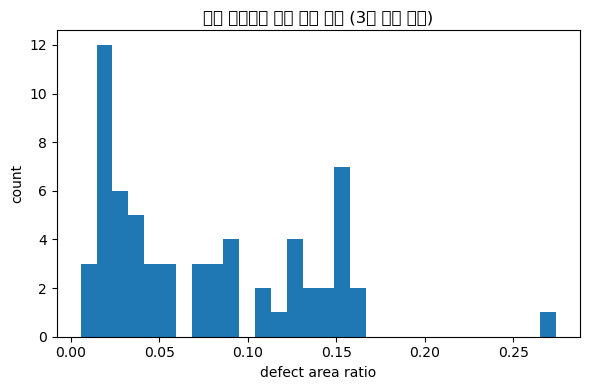

In [4]:
from notebooks.common import plot_distribution, plot_histogram

DEFECT_TYPES = ["broken_large", "broken_small", "contamination"]
defect_area_ratios = {}

for defect_type in DEFECT_TYPES:
    mask_paths = sorted(glob.glob(os.path.join(CATEGORY_DIR, "ground_truth", defect_type, "*_mask.png")))
    ratios = []
    for mask_path in mask_paths:
        mask_array = np.array(Image.open(mask_path).convert("L"))
        ratios.append(float((mask_array > 0).sum()) / mask_array.size)
    defect_area_ratios[defect_type] = ratios
    print(f"{defect_type}: {len(ratios)}장, 평균 결함 면적 비율 {sum(ratios)/len(ratios):.4f}")

all_ratios = [r for ratios in defect_area_ratios.values() for r in ratios]
plot_histogram(all_ratios, bins=30, title="결함 이미지당 결함 픽셀 비율 (3종 결함 전체)",
               xlabel="defect area ratio")

### 정상 이미지에 영행렬 마스크가 생성되는 것

`test/good`에는 `ground_truth` 디렉터리 자체가 없다 -- `MVTecAnomaly.__getitem__`은 이 경우
마스크를 생략하지 않고 `np.zeros((height, width))`를 만들어 채운다. 생략하면 pixel-level metric이
정상 이미지의 픽셀을 아예 보지 못한 채 계산되므로, 결함 이미지의 정상 부분과 결함 부분만으로
평가 모집단이 좁아진다 -- 이 경우 AUROC가 높아질지 낮아질지는 모델의 점수 분포에 달려 있어 방향을
단정할 수 없지만, 어느 쪽이든 실제로 배포될 "정상+이상이 섞인 전체 이미지" 모집단과는 다른 값을
보고하게 된다는 점에서 잘못된 평가다.

In [5]:
print(inspect.getsource(__import__(
    "src.tasks.anomaly.dataset", fromlist=["MVTecAnomaly"]).MVTecAnomaly.__getitem__))

    def __getitem__(self, index):
        sample_id = self.ids[index]
        defect_type, stem = sample_id.split("/", 1)
        image_path = self._image_path(defect_type, stem)

        try:
            image = Image.open(image_path).convert("RGB")
        except Exception as exc:
            raise RuntimeError(
                f"failed to load image '{image_path}' (sample_id='{sample_id}'): {exc}"
            ) from exc

        if self.split == "train":
            target = {}
            if self.transform is not None:
                return self.transform(image, target)
            import torchvision.transforms.v2.functional as F

            return F.to_dtype(F.to_image(image), torch.float32, scale=True), target

        is_anomalous = defect_type != "good"
        width, height = image.size
        if is_anomalous:
            mask_path = self._mask_path(defect_type, stem)
            try:
                mask_array = np.array(Image.open(mask_path).convert("L"))
            exce

### raw 샘플 그리드 -- 정상 vs 3종 결함

/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/eda.py:41: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review

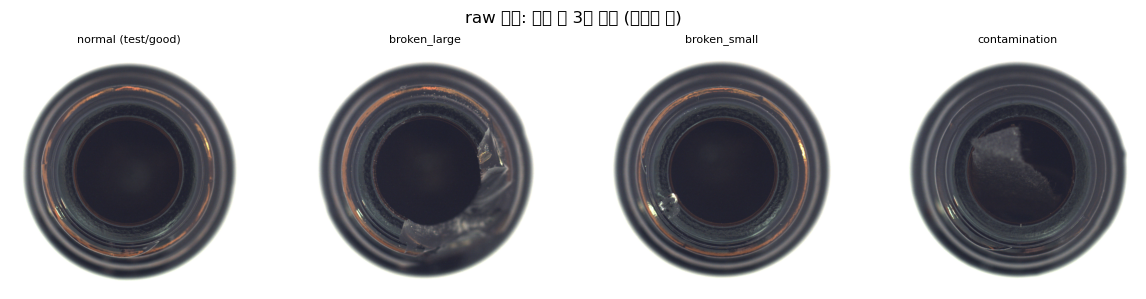

In [6]:
from notebooks.common import show_image_grid

sample_paths = [
    ("normal (test/good)", sorted(glob.glob(os.path.join(CATEGORY_DIR, "test", "good", "*.png")))[0]),
    ("broken_large", sorted(glob.glob(os.path.join(CATEGORY_DIR, "test", "broken_large", "*.png")))[0]),
    ("broken_small", sorted(glob.glob(os.path.join(CATEGORY_DIR, "test", "broken_small", "*.png")))[0]),
    ("contamination", sorted(glob.glob(os.path.join(CATEGORY_DIR, "test", "contamination", "*.png")))[0]),
]
grid_images = [Image.open(path).convert("RGB") for _title, path in sample_paths]
show_image_grid(grid_images, titles=[t for t, _p in sample_paths], ncols=4,
                 title="raw 샘플: 정상 대 3종 결함 (전처리 전)")

## 2. Dataset / DataLoader 출력 검증

여기서부터는 v0.1이 학습에 쓴 subset split(`configs/splits/mvtec_bottle.json`, 209/33/50)을
쓴다.

In [7]:
from src.core.registry import DATASETS

raw_train_ds = DATASETS.build("mvtec_anomaly", root=MVTEC_ROOT, split="train", transform=None,
                               split_path="configs/splits/mvtec_bottle.json", category="bottle")
raw_valid_ds = DATASETS.build("mvtec_anomaly", root=MVTEC_ROOT, split="valid", transform=None,
                               split_path="configs/splits/mvtec_bottle.json", category="bottle")

print("train split size:", len(raw_train_ds), " (전부 정상)")
print("valid split size:", len(raw_valid_ds), " (정상+이상 혼합)")

train_image, train_target = raw_train_ds[0]
print("\ntrain sample -- image:", train_image.shape, " target:", train_target, "(빈 dict -- toy_anomaly와 동일한 계약)")

train split size: 209  (전부 정상)
valid split size: 33  (정상+이상 혼합)

train sample -- image: torch.Size([3, 900, 900])  target: {} (빈 dict -- toy_anomaly와 동일한 계약)


In [8]:
# valid split에서 정상/이상 샘플을 각각 하나씩 찾아 비교
normal_sample = next((raw_valid_ds[i] for i in range(len(raw_valid_ds))
                       if int(raw_valid_ds[i][1]["label"]) == 0), None)
anomalous_sample = next((raw_valid_ds[i] for i in range(len(raw_valid_ds))
                          if int(raw_valid_ds[i][1]["label"]) == 1), None)

for name, (image, target) in [("정상", normal_sample), ("이상", anomalous_sample)]:
    print(f"{name} -- label: {int(target['label'])}  mask shape: {tuple(target['mask'].shape)}  "
          f"mask sum: {float(target['mask'].sum())}")

정상 -- label: 0  mask shape: (900, 900)  mask sum: 0.0
이상 -- label: 1  mask shape: (900, 900)  mask sum: 123810.0


### `collate_fn` -- 이미지는 스택, target은 list 유지

train의 target은 전부 빈 dict, valid/test의 target은 `{"label", "mask"}`를 가진 dict다. 어느
쪽이든 `anomaly_collate`는 이미지만 스택하고 target은 리스트로 유지한다 (`toy_anomaly`와 동일한
이유: 어댑터가 샘플별 dict 리스트 구조를 기대한다).

In [9]:
from src.core.registry import ADAPTERS, METRICS
from src.cli.commands import bind_class_names
from torch.utils.data import DataLoader

metrics = {"image_auroc": METRICS.build("image_auroc"), "pixel_auroc": METRICS.build("pixel_auroc")}
adapter = ADAPTERS.build("anomaly", None, metrics, smooth_sigma=4.0)
bind_class_names(adapter, raw_valid_ds)
print("adapter.collate_fn():", adapter.collate_fn())

from src.core.registry import TRANSFORMS

transform_eval = TRANSFORMS.build("anomaly_default", (256, 256), False)
transformed_valid_ds = DATASETS.build("mvtec_anomaly", root=MVTEC_ROOT, split="valid",
                                       transform=transform_eval,
                                       split_path="configs/splits/mvtec_bottle.json", category="bottle")

loader = DataLoader(transformed_valid_ds, batch_size=8, shuffle=False, collate_fn=adapter.collate_fn())
batch_images, batch_targets = next(iter(loader))
print("batch images:", batch_images.shape)
print("batch targets: list of", len(batch_targets), "dicts, labels =",
      [int(t["label"]) for t in batch_targets])

adapter.collate_fn(): <function anomaly_collate at 0x771b47b88ca0>


batch images: torch.Size([8, 3, 256, 256])
batch targets: list of 8 dicts, labels = [1, 1, 1, 1, 1, 1, 1, 1]


## 3. 모델별 섹션

`custom_ae`(재구성, from-scratch) -> `stfpm`(student-teacher distillation, ImageNet teacher) ->
`efficientad`(PDN teacher+student+AE, distilled teacher) 순서. 세 모델 모두 loss는 어댑터가 아니라
모델의 `train_step`에 있다 (`toy_anomaly`와 같은 이유 -- 세 방식의 loss 구성이 근본적으로 다르다).

In [10]:
from notebooks.common import FeatureMapRecorder, plot_training_curves, show_feature_maps, show_predictions
from src.core.checkpoint import load_checkpoint
from src.core.registry import MODELS
from src.utils.io import load_json

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sample_batch = next(iter(DataLoader(transformed_valid_ds, batch_size=8, shuffle=False,
                                     collate_fn=adapter.collate_fn())))


def load_model_for_split(model_name, split_name, **model_params):
    model = MODELS.build(model_name, **model_params)
    checkpoint_path = os.path.join(BENCH_DIR, "splits", split_name, "checkpoints", "best.pth")
    load_checkpoint(checkpoint_path, model, map_location="cpu", restore_rng=False)
    model.to(DEVICE)
    model.eval()
    return model


def restore_adapter_thresholds(split_name):
    """adapter.image_threshold/pixel_threshold start at None (AnomalyAdapter.__init__) and are
    only ever set inside on_fit_end (00_engine.ipynb SS5), which this notebook does not call --
    it only loads an already-trained checkpoint, it does not re-run trainer.fit(). Without this,
    predict_step's is_anomalous would stay None and the visualization's binarized panel would
    silently fall back to a 0.0 threshold (src/tasks/anomaly/visualize.py). The real valid-only
    thresholds v0.1 computed are persisted in metrics_final.json (AnomalyAdapter.
    extra_final_metrics), so restore them from there instead of recomputing or guessing."""
    metrics_final = load_json(os.path.join(BENCH_DIR, "splits", split_name, "metrics_final.json"))
    adapter.image_threshold = metrics_final["image_threshold"]
    adapter.pixel_threshold = metrics_final["pixel_threshold"]
    print(f"restored thresholds for '{split_name}': "
          f"image_threshold={adapter.image_threshold:.4f}, pixel_threshold={adapter.pixel_threshold:.4f}")

### 3.1 `custom_ae` -- 재구성 오차 (Autoencoder)

`src/tasks/anomaly/models/custom_ae.py`: 4-stage encoder-decoder가 이미지를 latent로 압축했다가
복원한다. 정상 이미지로만 학습하므로 정상 패턴은 잘 복원하지만 결함 영역은 본 적이 없어 복원에
실패한다 -- 그 픽셀별 복원 오차(MSE)가 그대로 anomaly map이다.

In [11]:
print(inspect.getsource(MODELS.get("custom_ae_anomaly").forward))

    def forward(self, images):
        recon = self.reconstruct(images)
        anomaly_map = (recon - images).pow(2).mean(dim=1)
        pred_score = anomaly_map.flatten(1).amax(dim=1)
        return {"pred_score": pred_score, "anomaly_map": anomaly_map}



In [12]:
ae_model = load_model_for_split("custom_ae_anomaly", "custom_ae", latent_channels=256)

with torch.no_grad():
    x = sample_batch[0].to(DEVICE)
    latent = ae_model.encoder(x)
    recon = ae_model.decoder(latent)
    print("latent:", tuple(latent.shape), " reconstruction:", tuple(recon.shape), " input:", tuple(x.shape))
    outputs = ae_model(x)
    print("anomaly_map:", tuple(outputs["anomaly_map"].shape), " pred_score:", tuple(outputs["pred_score"].shape))

latent: (8, 256, 16, 16)  reconstruction: (8, 3, 256, 256)  input: (8, 3, 256, 256)
anomaly_map: (8, 256, 256)  pred_score: (8,)


/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/features.py:46: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/features.py:46: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/nampl/anaconda3/envs/pytorch_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


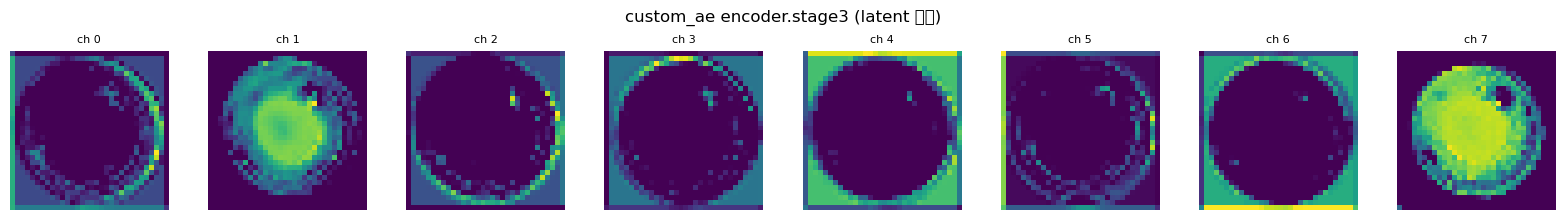

In [13]:
with FeatureMapRecorder(ae_model, "encoder.stage3") as recorder:
    with torch.no_grad():
        ae_model(x)
show_feature_maps(recorder.output, num_channels=8, title="custom_ae encoder.stage3 (latent 직전)")

restored thresholds for 'custom_ae': image_threshold=7.4908, pixel_threshold=0.1507


/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects

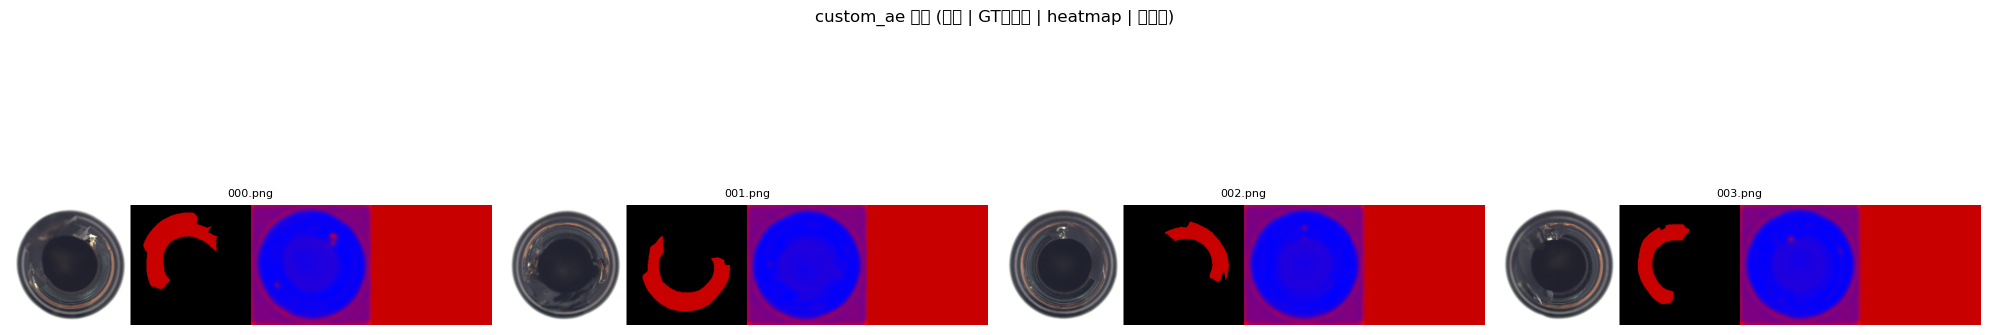

In [14]:
restore_adapter_thresholds("custom_ae")
with torch.no_grad():
    ae_predictions = adapter.predict_step(ae_model, sample_batch, DEVICE)
show_predictions(adapter, sample_batch, ae_predictions, max_items=4,
                  title="custom_ae 예측 (원본 | GT마스크 | heatmap | 이진화)")

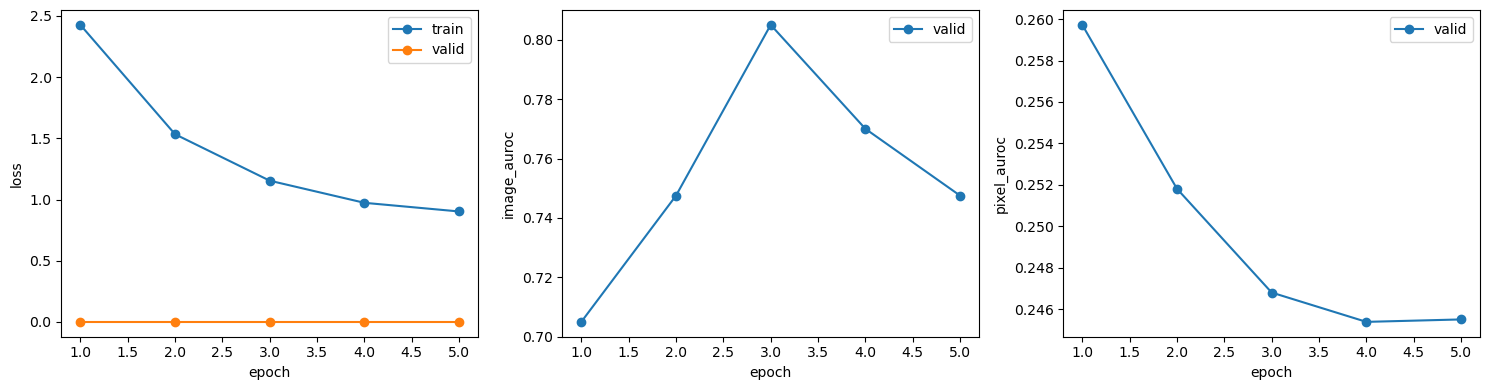

,epoch,split,loss,image_auroc,pixel_auroc,lr,elapsed_sec
44,1,train,2.427647,NaN,NaN,0.000100,3.493954
45,1,valid,0.000000,0.705000,0.259725,0.000000,1.118485
46,2,train,1.533661,NaN,NaN,0.000091,3.229349
47,2,valid,0.000000,0.747500,0.251808,0.000000,0.687777
48,3,train,1.153890,NaN,NaN,0.000066,3.088717
49,3,valid,0.000000,0.805000,0.246796,0.000000,0.674901
50,4,train,0.973067,NaN,NaN,0.000035,3.119759
51,4,valid,0.000000,0.770000,0.245380,0.000000,0.662873
52,5,train,0.902371,NaN,NaN,0.000010,3.366488
53,5,valid,0.000000,0.747500,0.245497,0.000000,0.657555


In [15]:
plot_training_curves(os.path.join(BENCH_DIR, "splits", "custom_ae", "metrics_epoch.csv"),
                      ["image_auroc", "pixel_auroc"])

### 3.2 `stfpm` -- Student-Teacher Feature Pyramid Matching (distillation)

`src/tasks/anomaly/models/stfpm.py`: ImageNet pretrained ResNet18을 얼린 채로 teacher로 쓰고,
같은 구조의 무작위 초기화 ResNet18(student)이 정상 이미지에서 teacher의 layer1/layer2/layer3
활성화를 흉내내도록 학습한다. 결함 영역은 학습 때 본 적이 없으니 student가 teacher를 잘 못 따라가고,
그 특징 차이(L2 거리)가 anomaly map이다. `custom_ae`가 이미지 자체를 재구성하는 것과 달리, 여기서는
**중간 특징 표현**을 재현하는 방식이다.

In [16]:
stfpm_model = load_model_for_split("stfpm_anomaly", "stfpm",
                                    weights_path="/mnt/d/backbones/resnet18-f37072fd.pth")

with torch.no_grad():
    x = sample_batch[0].to(DEVICE)
    teacher_features = stfpm_model.teacher(x)
    student_features = stfpm_model.student(x)
    for name in stfpm_model.feature_layers:
        print(f"{name}: teacher={tuple(teacher_features[name].shape)}  "
              f"student={tuple(student_features[name].shape)}")
    outputs = stfpm_model(x)
    print("\nanomaly_map:", tuple(outputs["anomaly_map"].shape))

layer1: teacher=(8, 64, 64, 64)  student=(8, 64, 64, 64)
layer2: teacher=(8, 128, 32, 32)  student=(8, 128, 32, 32)
layer3: teacher=(8, 256, 16, 16)  student=(8, 256, 16, 16)

anomaly_map: (8, 256, 256)


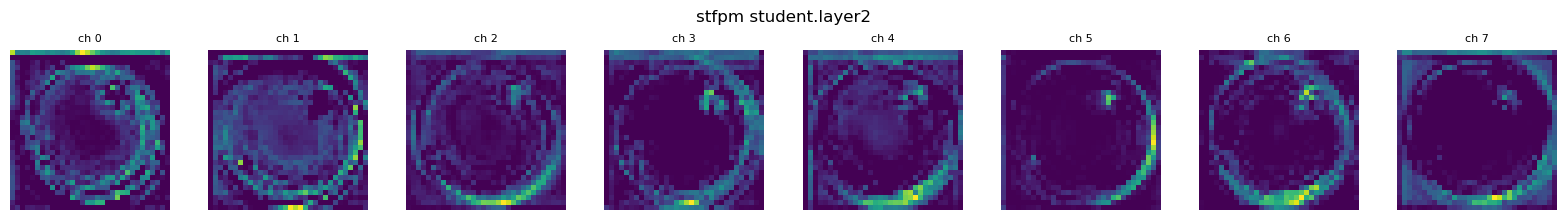

In [17]:
with FeatureMapRecorder(stfpm_model, "student.layer2") as recorder:
    with torch.no_grad():
        stfpm_model(x)
show_feature_maps(recorder.output, num_channels=8, title="stfpm student.layer2")

restored thresholds for 'stfpm': image_threshold=0.9913, pixel_threshold=0.8817


/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects

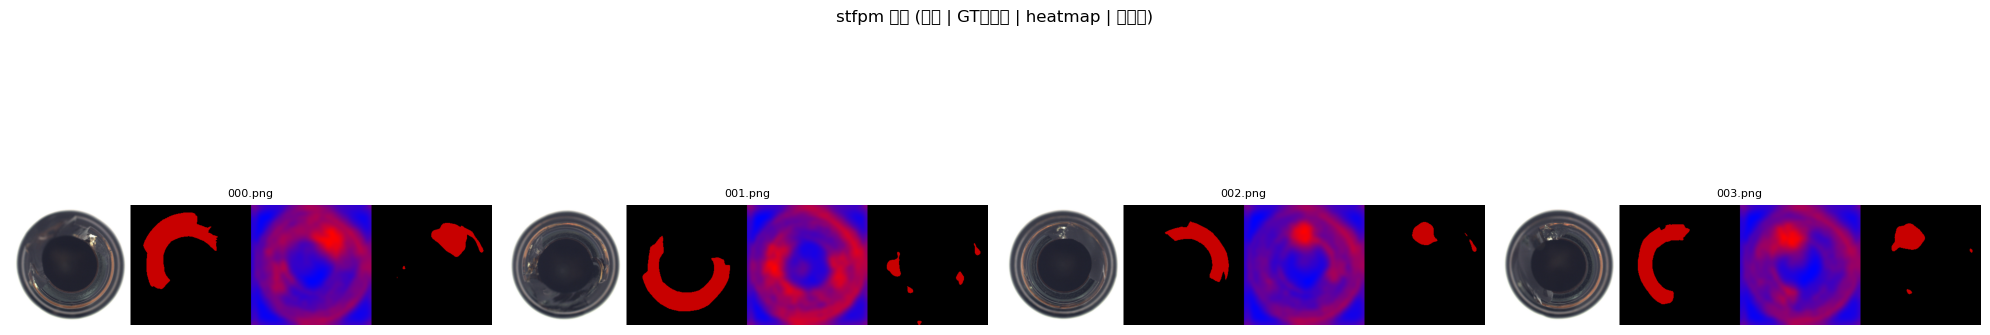

In [18]:
restore_adapter_thresholds("stfpm")
with torch.no_grad():
    stfpm_predictions = adapter.predict_step(stfpm_model, sample_batch, DEVICE)
show_predictions(adapter, sample_batch, stfpm_predictions, max_items=4,
                  title="stfpm 예측 (원본 | GT마스크 | heatmap | 이진화)")

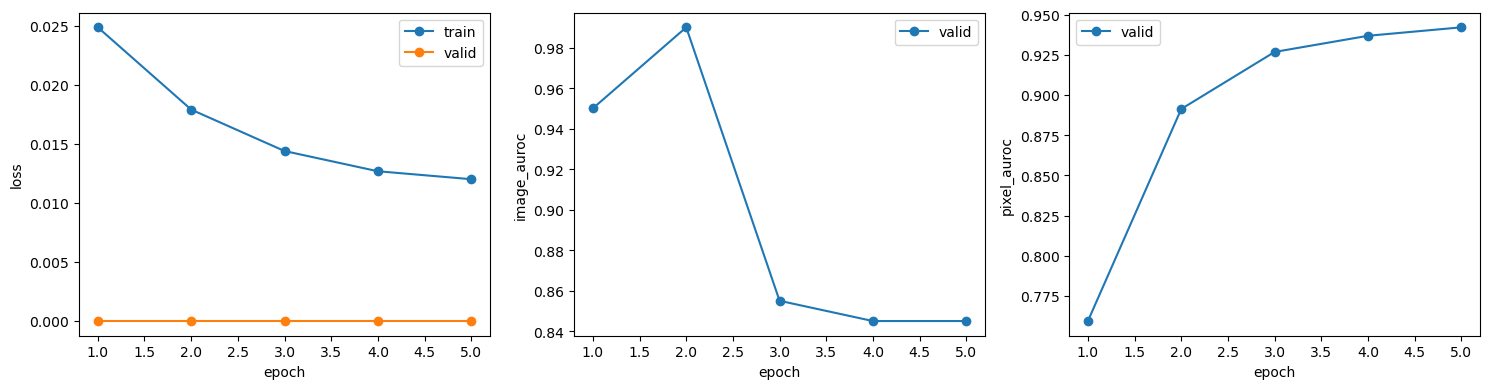

,epoch,split,loss,image_auroc,pixel_auroc,lr,elapsed_sec
44,1,train,0.024871,NaN,NaN,0.000100,3.567026
45,1,valid,0.000000,0.950000,0.759477,0.000000,0.784606
46,2,train,0.017905,NaN,NaN,0.000091,3.443670
47,2,valid,0.000000,0.990000,0.891318,0.000000,0.641950
48,3,train,0.014396,NaN,NaN,0.000066,3.211467
49,3,valid,0.000000,0.855000,0.926780,0.000000,0.599387
50,4,train,0.012683,NaN,NaN,0.000035,3.319147
51,4,valid,0.000000,0.845000,0.936822,0.000000,0.653422
52,5,train,0.012010,NaN,NaN,0.000010,3.374469
53,5,valid,0.000000,0.845000,0.942083,0.000000,0.626113


In [19]:
plot_training_curves(os.path.join(BENCH_DIR, "splits", "stfpm", "metrics_epoch.csv"),
                      ["image_auroc", "pixel_auroc"])

### 3.3 `efficientad` -- PDN teacher + student + autoencoder (distillation + 특징 재구성 결합)

`src/tasks/anomaly/models/efficientad.py`: `stfpm`과 같은 distillation(PDN teacher-student
특징 매칭)에 **특징 공간 재구성**을 더한다 -- `custom_ae`처럼 원본 이미지를 재구성하는 것이 아니라,
autoencoder가 **teacher의 (정규화된) 출력 특징**을 이미지로부터 재현하도록 학습된다. student는
teacher를 흉내내는 절반과 이 autoencoder 출력을 흉내내는 절반으로 나뉘어, 두 개의 서로 다른
anomaly 신호(student-teacher 거리, student-autoencoder 거리)를 만든다.

두 훅의 역할은 코드 주석과 아래 소스에 그대로 나타난다: `on_fit_start`는 train loader만 순회해
teacher 출력의 채널별 평균/표준편차를 계산하고, `on_fit_end`는 valid loader만 순회해 두 anomaly
map을 같은 척도로 합치기 위한 분위수(quantile) 정규화 상수를 계산한다. loader가 정확히 train-only/
valid-only로만 전달된다는 것은 `00_engine.ipynb` 5장에서 `on_fit_end`를 가로채(spy) 코드로
검증했다 -- 이 노트북은 재학습을 하지 않고 이미 학습된 체크포인트만 불러오므로, 여기서는 그 결과를
다시 훅과 함께 확인만 한다.

In [20]:
print(inspect.getsource(MODELS.get("efficientad_anomaly").on_fit_start))
print(inspect.getsource(MODELS.get("efficientad_anomaly").on_fit_end))

    @torch.no_grad()
    def on_fit_start(self, train_loader, device):
        # One pass over *train only* (PLAN-P5 SS5 constraint: no valid/test leakage here) to
        # compute the teacher's per-channel output mean/std on normal images.
        self.eval()
        channel_sum = torch.zeros(self.teacher_out_channels, device=device)
        channel_sq_sum = torch.zeros(self.teacher_out_channels, device=device)
        pixel_count = 0
        for images, _ in train_loader:
            images = images.to(device)
            teacher_out = self.teacher(images)
            channel_sum += teacher_out.sum(dim=(0, 2, 3))
            channel_sq_sum += teacher_out.pow(2).sum(dim=(0, 2, 3))
            pixel_count += teacher_out.shape[0] * teacher_out.shape[2] * teacher_out.shape[3]

        mean = channel_sum / pixel_count
        variance = (channel_sq_sum / pixel_count) - mean.pow(2)
        std = variance.clamp_min(1e-8).sqrt()
        self.teacher_mean.copy_(mean.view(1, -1, 1, 1))
      

In [21]:
efficientad_model = load_model_for_split(
    "efficientad_anomaly", "efficientad",
    weights_path="/mnt/d/backbones/efficientad_pretrained_weights/pretrained_teacher_small.pth")

print("on_fit_start/on_fit_end로 채워진 정규화 상수 (체크포인트에서 복원됨):")
print("  teacher_mean shape:", tuple(efficientad_model.teacher_mean.shape))
print("  qa_st/qb_st:", float(efficientad_model.qa_st), float(efficientad_model.qb_st))
print("  qa_ae/qb_ae:", float(efficientad_model.qa_ae), float(efficientad_model.qb_ae))

with torch.no_grad():
    x = sample_batch[0].to(DEVICE)
    map_st, map_ae = efficientad_model._raw_maps(x)
    print("\nmap_st (student-teacher):", tuple(map_st.shape))
    print("map_ae (student-autoencoder):", tuple(map_ae.shape))
    outputs = efficientad_model(x)
    print("combined anomaly_map:", tuple(outputs["anomaly_map"].shape))

on_fit_start/on_fit_end로 채워진 정규화 상수 (체크포인트에서 복원됨):
  teacher_mean shape: (1, 384, 1, 1)
  qa_st/qb_st: 3.6002700328826904 4.64939022064209
  qa_ae/qb_ae: 0.04476023092865944 0.06790169328451157

map_st (student-teacher): (8, 64, 64)
map_ae (student-autoencoder): (8, 64, 64)
combined anomaly_map: (8, 256, 256)


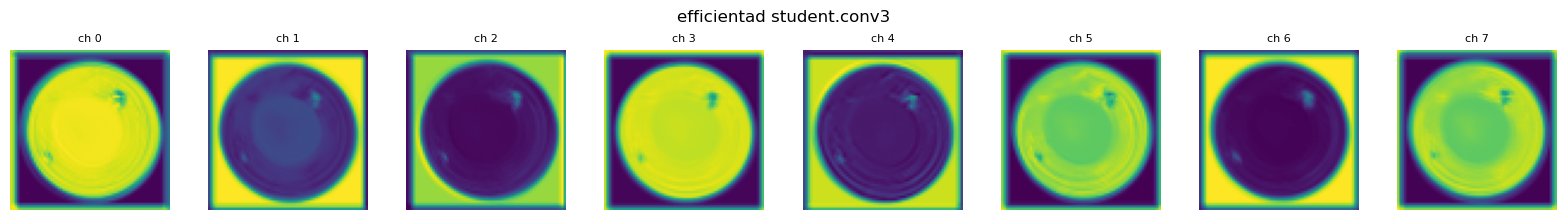

In [22]:
with FeatureMapRecorder(efficientad_model, "student.conv3") as recorder:
    with torch.no_grad():
        efficientad_model(x)
show_feature_maps(recorder.output, num_channels=8, title="efficientad student.conv3")

restored thresholds for 'efficientad': image_threshold=-0.2563, pixel_threshold=-0.6907


/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate/notebooks/common/overlays.py:31: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/mnt/d/projects

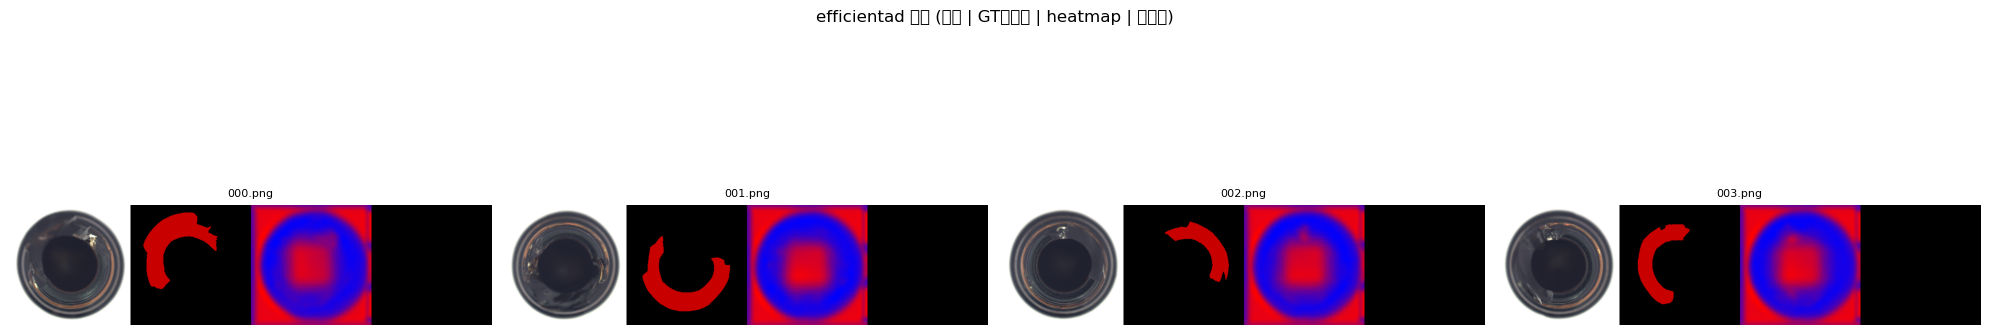

In [23]:
restore_adapter_thresholds("efficientad")
with torch.no_grad():
    efficientad_predictions = adapter.predict_step(efficientad_model, sample_batch, DEVICE)
show_predictions(adapter, sample_batch, efficientad_predictions, max_items=4,
                  title="efficientad 예측 (원본 | GT마스크 | heatmap | 이진화)")

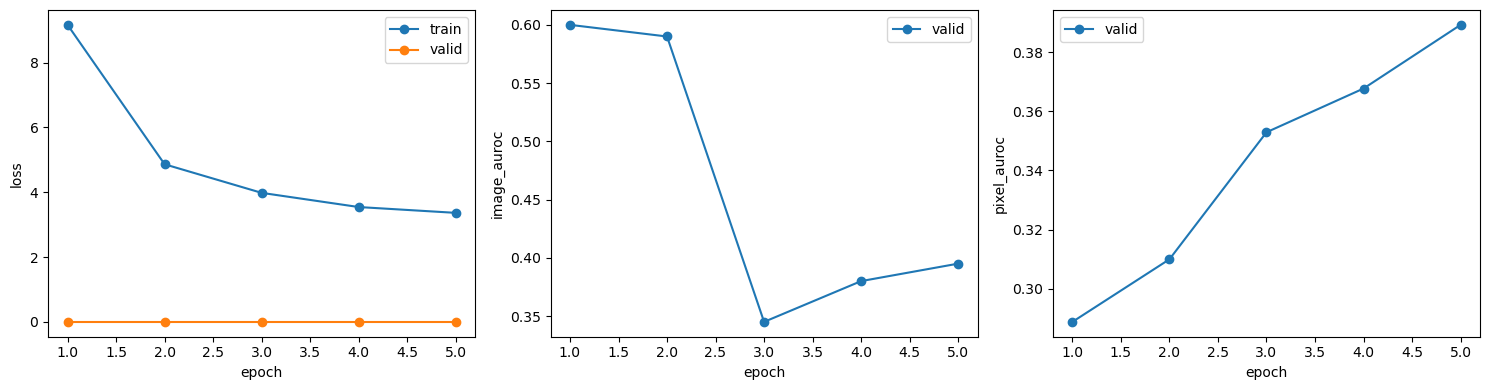

,epoch,split,loss,image_auroc,pixel_auroc,lr,elapsed_sec
44,1,train,9.168596,NaN,NaN,0.000100,6.859082
45,1,valid,0.000000,0.600000,0.288718,0.000000,1.143256
46,2,train,4.864694,NaN,NaN,0.000091,6.769893
47,2,valid,0.000000,0.590000,0.309925,0.000000,0.952161
48,3,train,3.982425,NaN,NaN,0.000066,6.767146
49,3,valid,0.000000,0.345000,0.352953,0.000000,0.958918
50,4,train,3.544724,NaN,NaN,0.000035,6.785058
51,4,valid,0.000000,0.380000,0.367768,0.000000,1.002493
52,5,train,3.365078,NaN,NaN,0.000010,6.818890
53,5,valid,0.000000,0.395000,0.389339,0.000000,0.969057


In [24]:
plot_training_curves(os.path.join(BENCH_DIR, "splits", "efficientad", "metrics_epoch.csv"),
                      ["image_auroc", "pixel_auroc"])

## 4. 3모델 비교

### image AUROC 대 pixel AUROC 강점 차이

세 모델의 학습 신호가 다르므로(이미지 재구성 vs 중간 특징 매칭 vs 결합), image-level과 pixel-level
metric에서 강점이 갈린다.

In [25]:
from notebooks.common import load_leaderboard, plot_tradeoff

leaderboard = load_leaderboard(os.path.join(BENCH_DIR, "leaderboard.csv"))
leaderboard[["split", "image_auroc", "pixel_auroc", "params_total", "flops_g", "fps"]]

,split,image_auroc,pixel_auroc,params_total,flops_g,fps
0,custom_ae,0.732456,0.259400,1380739,1.711276,235.215030
1,efficientad,0.539474,0.449320,7541504,91.004297,72.450764
2,stfpm,0.162281,0.856532,23379024,7.327449,89.523207


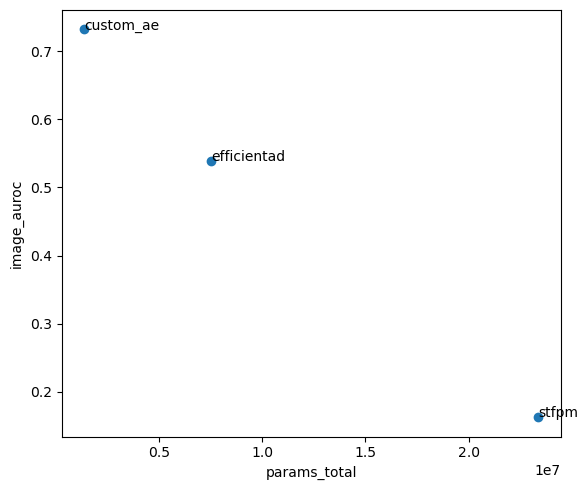

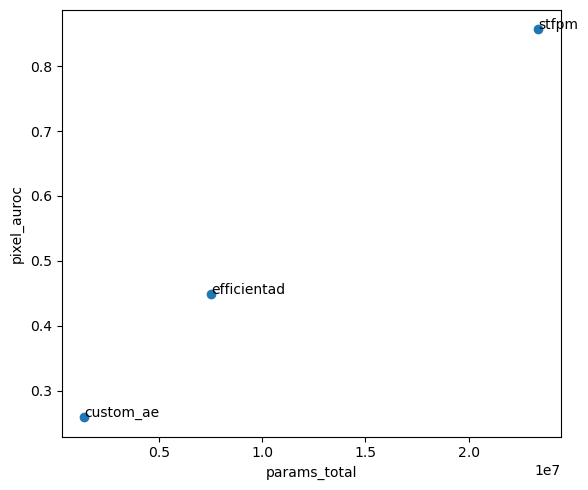

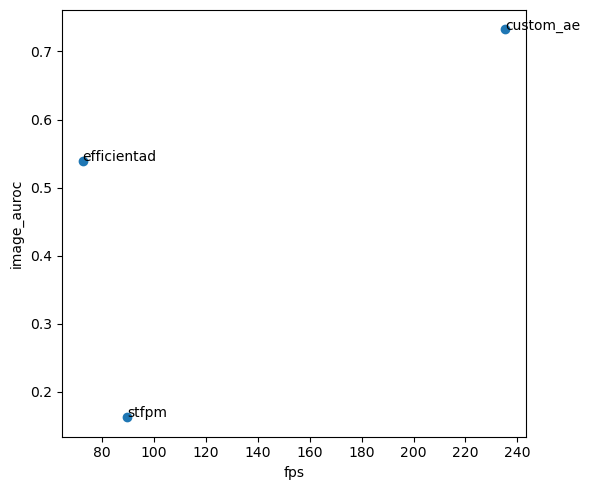

In [26]:
plot_tradeoff(leaderboard, "image_auroc", "params_total", label_column="split")
plot_tradeoff(leaderboard, "pixel_auroc", "params_total", label_column="split")
plot_tradeoff(leaderboard, "image_auroc", "fps", label_column="split")

이 5-epoch 벤치마크에서는 어떤 모델도 image/pixel AUROC 양쪽에서 압도적이지 않다 -- 각 방식이
포착하는 이상 신호의 종류(전역적 재구성 오차 대 국소적 특징 불일치)가 다르기 때문에, 정상 학습량이
적은 조건에서 강점이 쉽게 뒤집힌다. 이는 5 epoch라는 조건 자체의 한계이지 방법론의 우열을 뜻하지
않는다 (PLAN §13 비범위: 성능 개선은 이 노트북의 목적이 아니다).

### 통제 조건 확인 -- 실제 `control_report.json` 재사용

In [27]:
from src.bench.control import CONTROL_FIELDS
from src.utils.io import load_json, load_yaml

control_report = load_json(os.path.join(BENCH_DIR, "control_report.json"))
print(f"통제 대상 필드 {len(CONTROL_FIELDS)}개 (model.* 제외)")
print("violations (비어 있어야 한다):", control_report["violations"])
assert not control_report["violations"], "통제 필드에 미승인 차이가 있으면 안 된다"

# check_artifact()(준비 확인 셀)는 파일 존재 여부만 본다 -- checkpoint/leaderboard/
# control_report.json/config.resolved.yaml이 서로 같은 벤치마크 실행 결과인지는 보장하지 않는다.
# control_report가 기록한 split 집합과 leaderboard의 split 열이 이 노트북이 기대하는
# MODEL_SPLITS와 정확히 같은지 대조해, 불일치하는 부분 갱신을 놓치지 않는다.
assert set(control_report["expected_splits"]) == set(MODEL_SPLITS.keys()), (
    "control_report.json의 expected_splits가 MODEL_SPLITS와 다르다 -- outputs가 오래되었거나 "
    "부분적으로만 갱신됐을 수 있다.")
assert set(leaderboard["split"]) == set(MODEL_SPLITS.keys()), (
    "leaderboard.csv의 split 열이 MODEL_SPLITS와 다르다.")
print("-> control_report.json / leaderboard.csv / 이 노트북이 기대하는 split 집합이 모두 일치한다.")

resolved = {split_name: load_yaml(os.path.join(BENCH_DIR, "splits", split_name, "config.resolved.yaml"))
            for split_name in MODEL_SPLITS}
print("\nmodel 섹션 (통제 대상이 아니다):")
for split_name, cfg in resolved.items():
    print(f"  {split_name}: {cfg['model']}")

통제 대상 필드 22개 (model.* 제외)
violations (비어 있어야 한다): []
-> control_report.json / leaderboard.csv / 이 노트북이 기대하는 split 집합이 모두 일치한다.

model 섹션 (통제 대상이 아니다):
  custom_ae: {'name': 'custom_ae_anomaly', 'params': {'latent_channels': 256}}
  stfpm: {'name': 'stfpm_anomaly', 'params': {'weights_path': '/mnt/d/backbones/resnet18-f37072fd.pth'}}
  efficientad: {'name': 'efficientad_anomaly', 'params': {'weights_path': '/mnt/d/backbones/efficientad_pretrained_weights/pretrained_teacher_small.pth'}}


## 요약

- Anomaly Detection은 train target이 빈 dict `{}`(라벨 없음)이고 valid/test target은
  `{"label", "mask"}`다 -- `toy_anomaly`와 동일한 계약이 실데이터에서도 그대로다.
- `test/good`처럼 결함이 없는 이미지도 영행렬 마스크를 명시적으로 받는다 -- 생략하면 pixel AUROC의
  평가 모집단이 좁아져(정상 이미지의 픽셀이 통째로 빠짐) 실제 배포 환경과 다른 값을 보고하게 된다
  (오르내리는 방향은 모델의 점수 분포에 따라 다르다).
- 세 모델은 "정상만으로 학습"이라는 공통 전제 위에서 서로 다른 신호를 쓴다: `custom_ae`는 이미지
  자체의 재구성 오차, `stfpm`은 고정된 teacher 특징을 student가 흉내내지 못하는 정도(distillation),
  `efficientad`는 distillation에 특징 공간 재구성(teacher 출력을 이미지로부터 재현)을 더해 두
  신호를 함께 쓴다.
- `efficientad`의 `on_fit_start`/`on_fit_end`는 각각 train-only, valid-only로 정규화 상수를
  계산한다 -- `00_engine.ipynb`가 spy로 검증한 훅의 실제 활용 사례다.
- 이 노트북은 재학습 없이 체크포인트만 불러오므로, `on_fit_end`가 계산한 valid-only threshold는
  `adapter`가 자동으로 갖고 있지 않다 -- `metrics_final.json`에 저장된 값을 각 모델 섹션에서
  명시적으로 복원한 뒤에야 예측 시각화의 이진화 패널이 의미를 갖는다.
- 세 모델 모두 동일 통제 조건(`control_report.json`)에서 학습됐다.

`notebooks/tasks/` 4개 노트북에서 4개 태스크의 target 규약과 대표 모델들의 설계 의도를 실데이터와
실제 학습된 체크포인트 위에서 모두 확인했다.